In [ ]:
import pandas as pd
import numpy as np
import math as math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

<h1>Data Cleaning & Pre-processing + EDA</h1>

1) Load the Dataset

In [4]:
df = pd.read_csv("bank-full.csv", sep=";")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


2. Show First 5 Rows

In [6]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


3. Show Last 5 Rows

In [8]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


4) Check Dataset Shape

In [10]:
df.shape

(45211, 17)

5) Show Dataset Info

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


6. Show Column Names

In [14]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

7. Describe Columns

In [16]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


8. Sort dataset by age

In [18]:
df.sort_values("age")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
42954,18,student,single,unknown,no,108,no,no,cellular,9,feb,92,1,183,1,success,yes
41273,18,student,single,unknown,no,3,no,no,cellular,25,aug,130,2,-1,0,unknown,yes
42146,18,student,single,secondary,no,156,no,no,cellular,4,nov,298,2,82,4,other,no
43637,18,student,single,unknown,no,348,no,no,cellular,5,may,443,4,-1,0,unknown,yes
40736,18,student,single,primary,no,1944,no,no,telephone,10,aug,122,3,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44420,93,retired,married,unknown,no,775,no,no,cellular,4,aug,476,2,13,9,success,yes
44262,93,retired,married,unknown,no,775,no,no,cellular,22,jul,860,2,177,7,success,yes
31233,94,retired,divorced,secondary,no,1234,no,no,cellular,3,mar,212,1,-1,0,unknown,no
41663,95,retired,married,secondary,no,0,no,no,telephone,1,oct,215,1,-1,0,unknown,no


9. Check Duplicate Rows

In [20]:
df.duplicated().sum()

0

10. Unique Values of a Categorical Column

In [22]:
df["job"].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

11. Show number of columns

In [24]:
len(df.columns)

17

12. Show dataset index

In [26]:
df.index

RangeIndex(start=0, stop=45211, step=1)

13. Show column data types

In [28]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

14. Show summary of one column

In [44]:
df["age"].describe()

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

15. Find minimum value in age

In [47]:
df["age"].min()

18

16. Find unique count of job column

In [50]:
df["job"].nunique()

12

17. Count values in marital column

In [53]:
df["marital"].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

18. Find mean balance

In [56]:
df["balance"].mean()

1362.2720576850766

19. Filter dataset where job = 'management'

In [59]:
df[df["job"] == "management"]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
21,56,management,married,tertiary,no,779,yes,no,unknown,5,may,164,1,-1,0,unknown,no
26,39,management,single,tertiary,no,255,yes,no,unknown,5,may,296,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45192,29,management,single,tertiary,no,765,no,no,cellular,16,nov,238,1,-1,0,unknown,yes
45194,59,management,married,tertiary,no,138,yes,yes,cellular,16,nov,162,2,187,5,failure,no
45197,36,management,single,secondary,no,1511,yes,no,cellular,16,nov,270,1,-1,0,unknown,yes
45198,37,management,married,tertiary,no,1428,no,no,cellular,16,nov,333,2,-1,0,unknown,no


# Check Missing Values

In [64]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [66]:
(df == "unknown").sum()

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

# Handle missing values


In [162]:
# Mode Imputation for 'job' and 'education' to preserve data
for col in ['job', 'education']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].replace('unknown', mode_val)

# Verify no 'unknown' values remain
print("Remaining unknown values:")
print((df[['job', 'education']] == 'unknown').sum())


Remaining unknown values:
job          0
education    0
dtype: int64


# Identify and handle outliers.


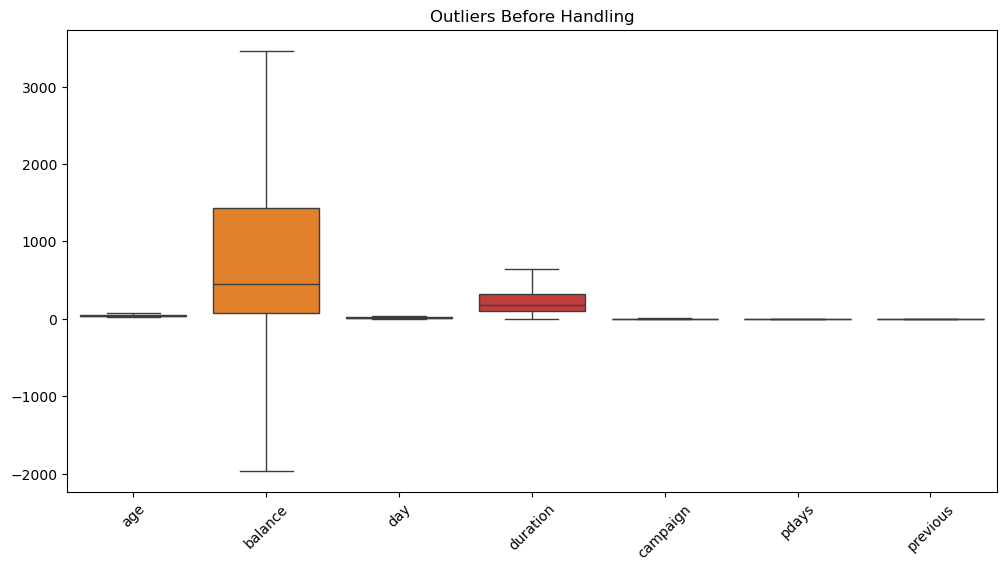

Outliers handled via Capping.


In [165]:
# 1. Visualize Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))
plt.xticks(rotation=45)
plt.title("Outliers Before Handling")
plt.show()

# 2. Handle Outliers using IQR Capping (Safe Method)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values instead of dropping rows
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outliers handled via Capping.")


# Encode categorical variables


In [167]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("Categorical variables encoded.")
df.head()


Categorical variables encoded.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,4,1,2,0,2143.0,1,0,2,5.0,8,261.0,1.0,-1.0,0.0,3,0
1,44.0,9,2,1,0,29.0,1,0,2,5.0,8,151.0,1.0,-1.0,0.0,3,0
2,33.0,2,1,1,0,2.0,1,1,2,5.0,8,76.0,1.0,-1.0,0.0,3,0
3,47.0,1,1,1,0,1506.0,1,0,2,5.0,8,92.0,1.0,-1.0,0.0,3,0
4,33.0,1,2,1,0,1.0,0,0,2,5.0,8,198.0,1.0,-1.0,0.0,3,0


# Normalize/scale numerical features.


In [169]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('y', axis=1) # features
y = df['y']              # target

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# Convert back to DataFrame to keep column names
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

print("Features scaled.")
X_scaled.head()


Features scaled.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,1.648117,-0.085217,-0.275762,1.314507,-0.13549,1.027653,0.893915,-0.436803,1.514306,-1.298476,0.823773,0.147445,-0.870092,0.0,0.0,0.444898
1,0.301287,1.458223,1.368372,-0.218740,-0.13549,-0.768817,0.893915,-0.436803,1.514306,-1.298476,0.823773,-0.474910,-0.870092,0.0,0.0,0.444898
2,-0.756936,-0.702593,-0.275762,-0.218740,-0.13549,-0.791761,0.893915,2.289359,1.514306,-1.298476,0.823773,-0.899243,-0.870092,0.0,0.0,0.444898
3,0.589894,-1.011281,-0.275762,-0.218740,-0.13549,0.486333,0.893915,-0.436803,1.514306,-1.298476,0.823773,-0.808718,-0.870092,0.0,0.0,0.444898
4,-0.756936,-1.011281,1.368372,-0.218740,-0.13549,-0.792611,-1.118674,-0.436803,1.514306,-1.298476,0.823773,-0.208994,-0.870092,0.0,0.0,0.444898


# EDA


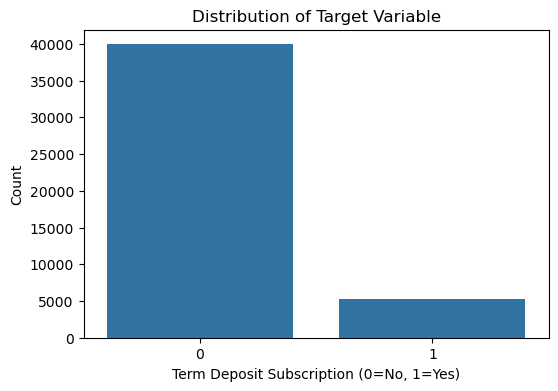

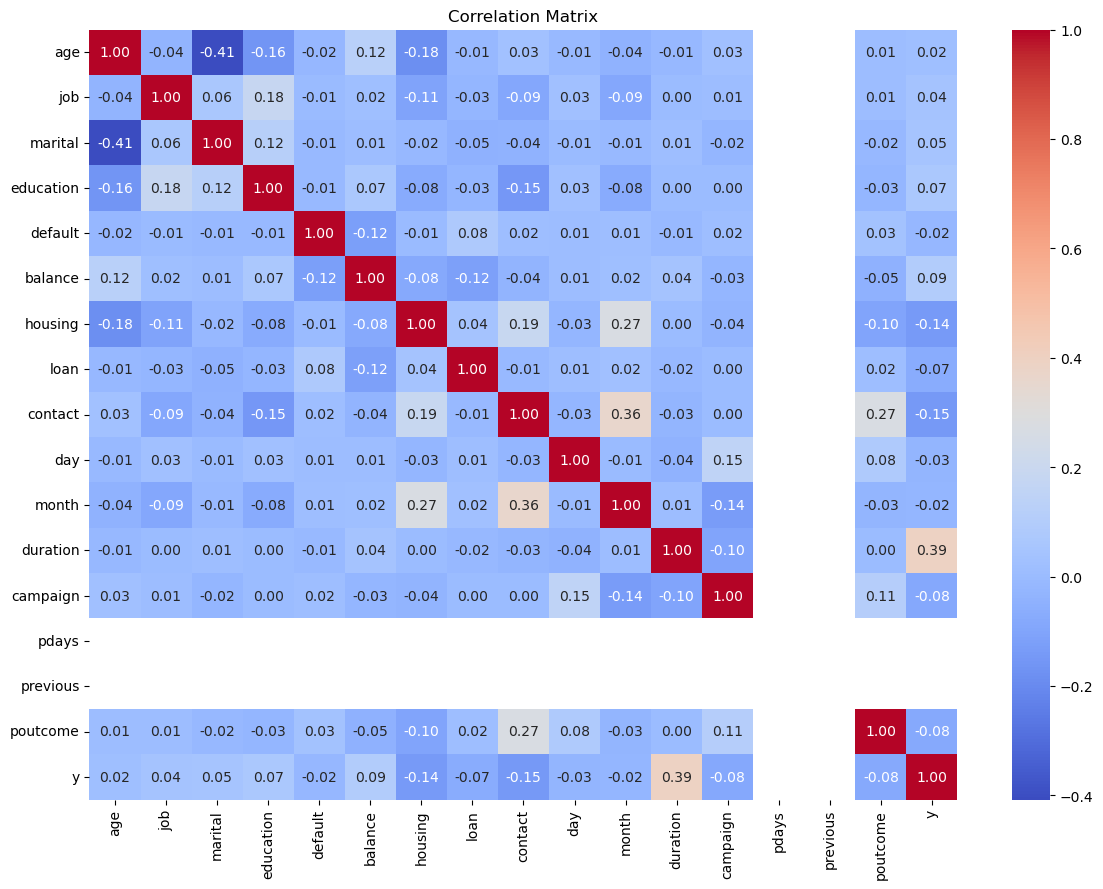

In [171]:
# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribution of Target Variable")
plt.xlabel("Term Deposit Subscription (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

# Correlation Matrix
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


In [173]:
df.to_csv("cleaned_data.csv", index=False)
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,4,1,2,0,2143.0,1,0,2,5.0,8,261.0,1.0,-1.0,0.0,3,0
1,44.0,9,2,1,0,29.0,1,0,2,5.0,8,151.0,1.0,-1.0,0.0,3,0
2,33.0,2,1,1,0,2.0,1,1,2,5.0,8,76.0,1.0,-1.0,0.0,3,0
3,47.0,1,1,1,0,1506.0,1,0,2,5.0,8,92.0,1.0,-1.0,0.0,3,0
4,33.0,1,2,1,0,1.0,0,0,2,5.0,8,198.0,1.0,-1.0,0.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51.0,9,1,2,0,825.0,0,0,0,17.0,9,643.0,3.0,-1.0,0.0,3,1
45207,70.5,5,0,0,0,1729.0,0,0,0,17.0,9,456.0,2.0,-1.0,0.0,3,1
45208,70.5,5,1,1,0,3462.0,0,0,0,17.0,9,643.0,5.0,-1.0,0.0,2,1
45209,57.0,1,1,1,0,668.0,0,0,1,17.0,9,508.0,4.0,-1.0,0.0,3,0
